<a href="https://colab.research.google.com/github/xfalconix/Creditcard_fraud_prediction/blob/main/Creditcard_redneuronal_2025_12_10_rev00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fecha: 2025 - 12 - 10 - ESESA - Málaga - Spain.

# Red Neuronal Autoencoder para Detección de Fraude en Tarjetas de Crédito

El objetivo es identificar transacciones fraudulentas



Fuente: [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score

plt.rcParams['figure.figsize'] = [4.5, 3]

In [5]:
# Dataset de Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
df = pd.read_csv("/content/drive/MyDrive/2025 ESESA/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Exploración de datos (EDA)

In [7]:
# Dimensiones del dataset
print("Filas y columnas:", df.shape)
print()
# Verificar que no hay nulos
print("Valores nulos por columna:")
print(df.isnull().sum().sum(), "valores nulos en total")

Filas y columnas: (284807, 31)

Valores nulos por columna:
0 valores nulos en total


In [8]:
# Distribución de la variable objetivo
print(df["Class"].value_counts())
print(f"\nPorcentaje de fraudes: {df['Class'].mean()*100:.2f}%")

Class
0    284315
1       492
Name: count, dtype: int64

Porcentaje de fraudes: 0.17%


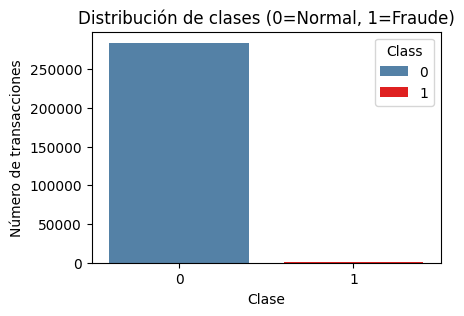

In [9]:
# El dataset está muy desbalanceado — casi todas las transacciones son normales
sns.countplot(x=df["Class"], hue=df["Class"], palette=["steelblue", "red"])
plt.title("Distribución de clases (0=Normal, 1=Fraude)")
plt.xlabel("Clase")
plt.ylabel("Número de transacciones")
plt.show()

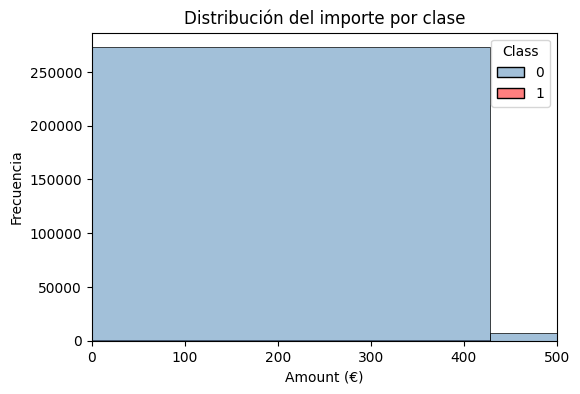

In [10]:
# El importe de las transacciones fraudulentas tiende a ser más bajo
plt.rcParams['figure.figsize'] = [6, 4]
sns.histplot(x=df["Amount"], hue=df["Class"], palette=["steelblue", "red"], bins=60)
plt.title("Distribución del importe por clase")
plt.xlabel("Amount (€)")
plt.ylabel("Frecuencia")
plt.xlim(0, 500)
plt.show()
plt.rcParams['figure.figsize'] = [4.5, 3]

In [11]:
# Resumen estadístico del importe según clase
df.groupby("Class")["Amount"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
Class,,,,
0,0.0,25691.16,88.291022,284315
1,0.0,2125.87,122.211321,492


Preparación de datos


In [12]:
# Guardamos las etiquetas reales antes de eliminar la columna
y = df["Class"]

# Eliminamos Time (no aporta al modelo) y Class (es lo que queremos predecir)
df_features = df.drop(columns=["Time", "Class"])

print("Features usadas:", df_features.shape[1])
df_features.head()

Features usadas: 29


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [13]:
# Normalizamos entre 0 y 1 — necesario para que la red neuronal converja bien
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_features)

print("Forma de los datos escalados:", df_scaled.shape)
print("Rango mínimo:", df_scaled.min().round(4))
print("Rango máximo:", df_scaled.max().round(4))

Forma de los datos escalados: (284807, 29)
Rango mínimo: 0.0
Rango máximo: 1.0


Autoencoder — Red Neuronal para Detección de Anomalías

In [14]:
from keras import Sequential
from keras.layers import Dense

# Arquitectura en embudo: comprime de 29 features hasta 5 neuronas y luego reconstruye
model = Sequential()
model.add(Dense(30, activation="tanh", input_dim=29))
model.add(Dense(20, activation="tanh"))
model.add(Dense(10, activation="tanh"))
model.add(Dense(5,  activation="tanh"))   # cuello de botella
model.add(Dense(10, activation="tanh"))
model.add(Dense(20, activation="tanh"))
model.add(Dense(30, activation="tanh"))
model.add(Dense(29, activation="tanh"))  # reconstruye las 29 variables originales

# loss=mse porque queremos minimizar el error cuadrático de reconstrucción
model.compile(loss="mse", metrics=["mae"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 29)             │           899 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,594 (14.04 KB)

 Trainable params: 3,594 (14.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Entrenamos con los propios datos como entrada y salida (X → X)
history = model.fit(df_scaled, df_scaled, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.0016 - mae: 0.0235
Epoch 2/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 8.4321e-04 - mae: 0.0181
Epoch 3/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 7.9110e-04 - mae: 0.0174
Epoch 4/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 7.7122e-04 - mae: 0.0169
Epoch 5/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 7.6126e-04 - mae: 0.0166
Epoch 6/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 7.5498e-04 - mae: 0.0164
Epoch 7/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 7.5022e-04 - mae: 0.0163
Epoch 8/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 7.4653e-04 - mae: 0.0162
Epoch 9/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 7.4237e-04 - mae: 0.0161
Epoch 10/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 7.3642e-04 - mae: 0.0161
Epoch 11/20
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 7.2723e-04 - mae: 0.0162
Epoch 12/20
8901/8901 ━━━━━━━━━━━━

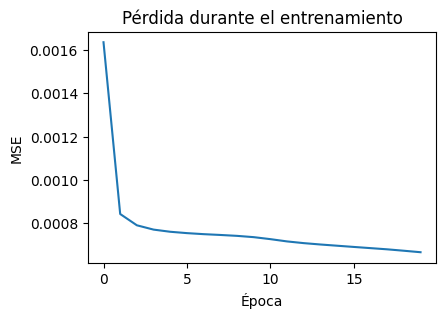

In [16]:
# Visualizamos cómo baja el error durante el entrenamiento
plt.plot(history.history["loss"])
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.show()

## 4. Error de Reconstrucción

Una vez entrenado el modelo, lo aplicamos sobre todos los datos.  
Calculamos la **suma de diferencias cuadráticas** entre la entrada original y la salida reconstruida:  
cuanto mayor es ese error, más diferente es la transacción a las normales.

In [23]:
# La red intenta reconstruir cada transacción
df_pred = model.predict(df_scaled)

8901/8901 ━━━━━━━━━━━━━━━━━━━━ 7s 787us/step


In [18]:
# Error de reconstrucción: suma de (original - predicho)^2 por cada fila
distancias = ((df_scaled - df_pred) ** 2).sum(axis=1)
print("Primeros 5 errores:", distancias[:5].round(5))

Primeros 5 errores: [0.0103  0.0167  0.03002 0.03993 0.00653]


In [19]:
# Estadísticos del error — usaremos estos para definir el umbral
media = distancias.mean()
std = distancias.std()
umbral = media + 4 * std

print(f"Media del error:          {media:.4f}")
print(f"Desviación típica:        {std:.4f}")
print(f"Umbral (media + 4*std):   {umbral:.4f}")

Media del error:          0.0201
Desviación típica:        0.0290
Umbral (media + 4*std):   0.1362


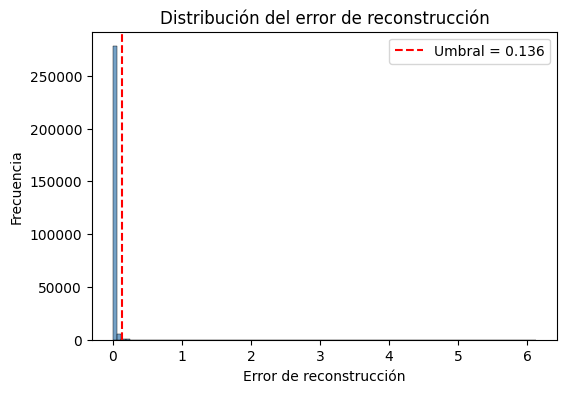

In [28]:
# Visualizamos la distribución del error de reconstrucción
# Las transacciones con error muy alto son candidatas a fraude
plt.rcParams['figure.figsize'] = [6, 4]
sns.histplot(distancias, bins=100, color="steelblue")
plt.axvline(umbral, color="red", linestyle="--", label=f"Umbral = {umbral:.3f}")
plt.xlabel("Error de reconstrucción")
plt.ylabel("Frecuencia")
plt.title("Distribución del error de reconstrucción")
plt.legend()
plt.show()
plt.rcParams['figure.figsize'] = [4.5, 3]

## 5. Detección de Anomalías

Marcamos como fraude "1" las transacciones cuyo error de reconstrucción supera el umbral.  
El umbral de  " media + 4 desviaciones típicas " es estricto: sólo pasan los errores verdaderamente atípicos.

In [21]:
# Clasificamos como fraude si el error supera el umbral
y_predicho = np.array([1 if distancia > umbral else 0 for distancia in distancias])

print(f"Fraudes detectados por el modelo: {y_predicho.sum()}")
print(f"Fraudes reales en el dataset:     {y.sum()}")

Fraudes detectados por el modelo: 1461
Fraudes reales en el dataset:     492


## 6. Evaluación del Modelo

Comparamos las predicciones con las etiquetas reales.  
En detección de fraude, el **Recall** es la métrica más importante:  
preferimos detectar todos los fraudes aunque haya algunas falsas alarmas.

In [22]:
# Matriz de confusión
print(pd.crosstab(y, y_predicho, rownames=["Real"], colnames=["Predicho"]))
print()

# Métricas principales
print(f"Precision: {precision_score(y, y_predicho):.3f}")
print(f"Recall:    {recall_score(y, y_predicho):.3f}")

Predicho       0     1
Real                  
0         283035  1280
1            311   181

Precision: 0.124
Recall:    0.368


## 7. Conclusiones

- El **autoencoder** aprende a reconstruir bien las transacciones normales porque son la inmensa mayoría del dataset.
- Las transacciones fraudulentas, al ser distintas, generan un **error de reconstrucción mayor** y son detectadas como anomalías.
- Ajustando el umbral podemos priorizar **Recall** (detectar más fraudes) o **Precision** (reducir falsas alarmas).
- Este enfoque es **no supervisado**: el modelo no necesita ver ejemplos de fraude para aprender — sólo aprende cómo son las transacciones normales.